In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/advertising.csv")
print("Shape:", df.shape)
df.head()

Shape: (200, 5)


,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
# Drop the unnecessary index column
df = df.drop(columns=['Unnamed: 0'])

# Rename columns to simpler names for easier coding
df.columns = ['TV', 'Radio', 'Newspaper', 'Sales']

# Basic info
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDescriptive statistics:")
print(df.describe())

Shape: (200, 4)

Missing values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Descriptive statistics:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


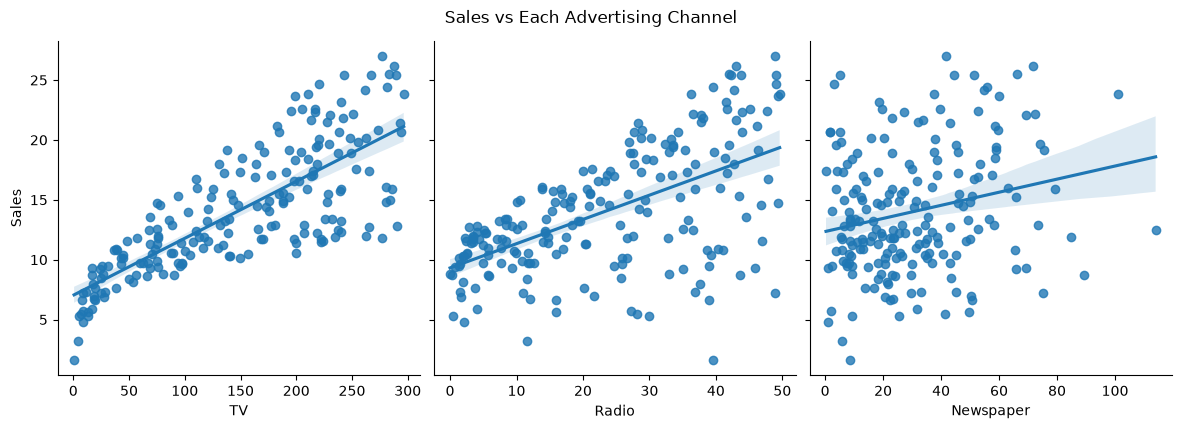

In [4]:
# Pairplot to see relationships between all variables
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=4, aspect=1, kind='reg')
plt.suptitle('Sales vs Each Advertising Channel', y=1.05)
plt.savefig('../models/scatter_plots.png', dpi=100, bbox_inches='tight')
plt.show()

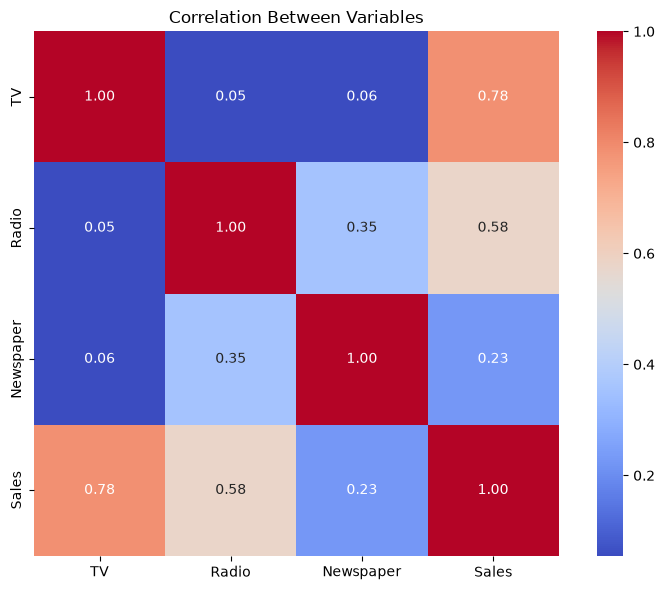

Sales        1.000000
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64


In [5]:
plt.figure(figsize=(8, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Between Variables')
plt.tight_layout()
plt.savefig('../models/correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print(correlation_matrix['Sales'].sort_values(ascending=False))

In [6]:
# Create an interaction feature: TV and Radio combined effect
df['TV_Radio_Interaction'] = df['TV'] * df['Radio']

# Check its correlation with Sales
print("Correlation of TV_Radio_Interaction with Sales:", df['TV_Radio_Interaction'].corr(df['Sales']))

df.head()

Correlation of TV_Radio_Interaction with Sales: 0.963932045992048


,TV,Radio,Newspaper,Sales,TV_Radio_Interaction
0,230.1,37.8,69.2,22.1,8697.78
1,44.5,39.3,45.1,10.4,1748.85
2,17.2,45.9,69.3,9.3,789.48
3,151.5,41.3,58.5,18.5,6256.95
4,180.8,10.8,58.4,12.9,1952.64


In [10]:
# Include the interaction feature along with original features
X = df[['TV', 'Radio', 'Newspaper', 'TV_Radio_Interaction']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (160, 4)
Testing data size: (40, 4)


In [9]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=42),
    'Lasso Regression': Lasso(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

print("5-fold Cross-Validation R² scores:\n")

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    cv_results[name] = scores
    print(f"{name}: Mean R² = {scores.mean():.4f} (+/- {scores.std():.4f})")

NameError: name 'GradientBoostingRegressor' is not defined

In [11]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=42),
    'Lasso Regression': Lasso(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

print("5-fold Cross-Validation R² scores:\n")

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    cv_results[name] = scores
    print(f"{name}: Mean R² = {scores.mean():.4f} (+/- {scores.std():.4f})")

5-fold Cross-Validation R² scores:

Linear Regression: Mean R² = 0.9536 (+/- 0.0263)
Ridge Regression: Mean R² = 0.9536 (+/- 0.0263)
Lasso Regression: Mean R² = 0.9550 (+/- 0.0214)
Random Forest: Mean R² = 0.9861 (+/- 0.0055)
Gradient Boosting: Mean R² = 0.9879 (+/- 0.0042)


In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3, 4]
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation R²:", grid_search.best_score_)

Best parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
Best cross-validation R²: 0.9881544580372846


In [13]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test Set Performance:")
print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Test Set Performance:
MAE (Mean Absolute Error): 0.3720
RMSE (Root Mean Squared Error): 0.5214
R² Score: 0.9914


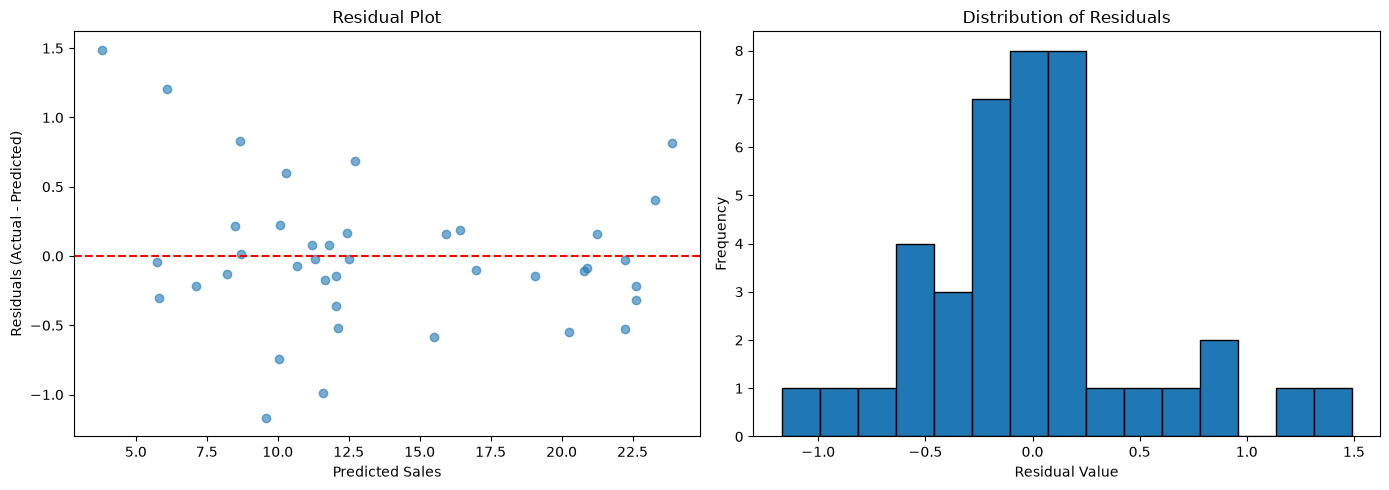

In [14]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs predicted values
axes[0].scatter(y_pred, residuals, alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Sales')
axes[0].set_ylabel('Residuals (Actual - Predicted)')
axes[0].set_title('Residual Plot')

# Distribution of residuals
axes[1].hist(residuals, bins=15, edgecolor='black')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.savefig('../models/residual_plots.png', dpi=100, bbox_inches='tight')
plt.show()

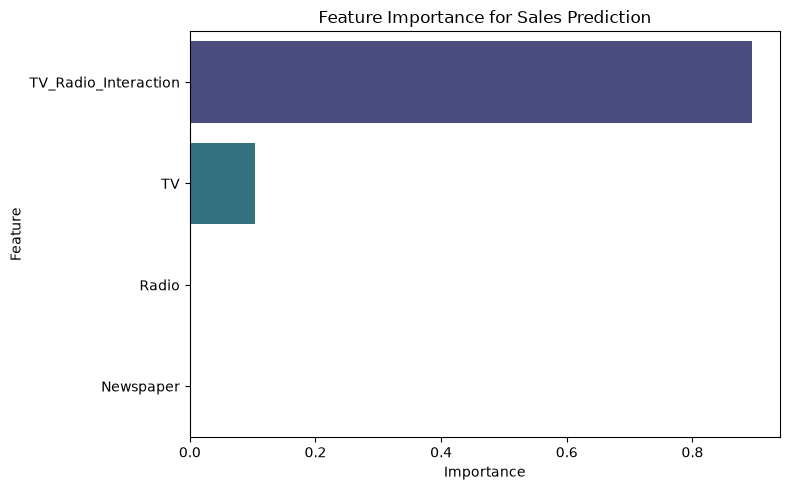

                Feature  Importance
3  TV_Radio_Interaction    0.894710
0                    TV    0.102967
1                 Radio    0.001500
2             Newspaper    0.000823


In [15]:
importances = best_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature', legend=False, palette='viridis')
plt.title('Feature Importance for Sales Prediction')
plt.tight_layout()
plt.savefig('../models/feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print(importance_df)

In [16]:
import joblib

joblib.dump(best_model, '../models/sales_prediction_model.pkl')

print("Model saved successfully!")

Model saved successfully!


Conclusion

This project builds a regression model to predict product sales based on advertising spend across TV, Radio, and Newspaper channels, using the classic Advertising dataset.

Initial correlation analysis showed TV had the strongest individual relationship with sales (0.78), followed by Radio (0.58), while Newspaper had a weak relationship (0.23). A TV and Radio interaction feature was created by multiplying the two budgets together, and this new feature showed a much stronger correlation with sales (0.96) than either channel alone, suggesting a real synergy effect between the two channels.

Five models were compared using 5-fold cross-validation: Linear Regression, Ridge Regression, Lasso Regression, Random Forest, and Gradient Boosting. Gradient Boosting performed best (98.79% R² in cross-validation) and was further tuned using